# 03 Business Analysis

This notebook delivers the Phase 2 business-facing analysis for **Netflix Catalog Strategy Analysis**. It uses the cleaned and normalized Phase 1 outputs to answer five core questions:

- How is the catalog structured across Movies and TV Shows?
- How fresh is the catalog, and how long after release do titles get added?
- How concentrated or international is the production-country footprint?
- What does the maturity mix imply about audience positioning?
- Which genre combinations represent coherent catalog strategies versus weak overlaps?

The analysis stays within the limits of metadata. It does **not** infer viewership, popularity, retention, or business performance.

In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data/processed/titles.csv').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))
pd.options.display.float_format = lambda value: f'{value:,.3f}'

from src.feature_engineering import (
    build_country_view,
    build_genre_view,
    build_title_features,
    load_phase1_tables,
    select_top_entities,
)
from src.metrics import (
    concentration_curve,
    concentration_summary,
    country_scope_summary,
    distribution_table,
    freshness_summary,
    matrix_from_mix,
    mix_table,
    pair_lift_table,
    share_table,
    top_entities_over_time,
)
from src.utils import ensure_directory, save_dataframe
from src.visualization import (
    RATING_COLORS,
    apply_report_style,
    plot_concentration_curves,
    plot_country_footprint,
    plot_country_mix_over_time,
    plot_freshness_panels,
    plot_pair_lift_heatmap,
    plot_rating_heatmaps,
    plot_release_lag_by_type,
    plot_stacked_mix,
    plot_top_genres_by_type,
    plot_type_mix,
    plot_year_distributions,
    save_figure,
)

TABLES_DIR = ensure_directory(PROJECT_ROOT / 'outputs/tables')
FIGURES_DIR = ensure_directory(PROJECT_ROOT / 'outputs/figures')

def show_figure(file_name: str, width: int = 980) -> None:
    display(Image(filename=str(FIGURES_DIR / file_name), width=width))

## Analytical Notes

- `release_to_add_lag_clean` is the Phase 2 freshness metric. It excludes 9 records where `year_added < release_year`, which are treated as metadata anomalies rather than real negative lag.
- Country analysis is based on normalized `title_country` tags. Because some titles have multiple countries, country totals represent tagged title-country relationships rather than mutually exclusive market shares.
- `date_added_year = 2020` should be treated as snapshot-year data, not a full comparable year.
- Rating groups are heuristic portfolio buckets created in Phase 1 to make mixed movie and TV rating systems more interpretable.

In [2]:
apply_report_style()

tables = load_phase1_tables(PROJECT_ROOT / 'data/processed')
title_features = build_title_features(tables['titles'], tables['title_country'], tables['title_genre'])
country_view = build_country_view(title_features, tables['title_country'])
genre_view = build_genre_view(title_features, tables['title_genre'])

display(title_features[['show_id', 'title', 'type', 'release_year', 'date_added_year', 'rating_group', 'country_count', 'genre_count', 'release_to_add_lag_clean']].head())

,show_id,title,type,release_year,date_added_year,rating_group,country_count,genre_count,release_to_add_lag_clean
0,1005494,The Stranger,Movie,1946,2018,Family,1,3,72
1,1008581,Stripes,Movie,1981,2019,Mature,1,3,38
2,1029730,Teenage Mutant Ninja Turtles: The Movie,Movie,1990,2020,Family,0,2,30
3,1064058,Tremors 2: Aftershocks,Movie,1995,2020,Teen,0,3,25
4,1065372,The Trigger Effect,Movie,1996,2018,Mature,1,1,22


In [3]:
portfolio_type_mix = share_table(title_features, 'type')
rating_distribution_overall = share_table(title_features, 'rating_group')
rating_mix_by_type = mix_table(title_features, 'type', 'rating_group')
genre_mix_by_type = mix_table(genre_view, 'type', 'genre')
genre_share = share_table(genre_view, 'genre')
country_ranking = share_table(country_view, 'country')
release_year_distribution = distribution_table(title_features, 'release_year')
year_added_distribution = distribution_table(title_features, 'date_added_year')

freshness_by_type = freshness_summary(title_features, 'type')
freshness_by_rating = freshness_summary(title_features, 'rating_group')
freshness_by_genre = freshness_summary(genre_view, 'genre')
freshness_by_country = freshness_summary(country_view, 'country')

country_scope_by_type = country_scope_summary(title_features)
country_scope_overall = share_table(title_features, 'country_scope')
country_mix_over_time = top_entities_over_time(country_view, 'country', top_n=5)

concentration_summary_table = pd.concat(
    [
        concentration_summary(title_features, 'type'),
        concentration_summary(title_features, 'rating_group'),
        concentration_summary(genre_view, 'genre'),
        concentration_summary(country_view, 'country'),
    ],
    ignore_index=True,
)

genre_concentration_curve = concentration_curve(genre_view, 'genre')
country_concentration_curve = concentration_curve(country_view, 'country')

top_genres = select_top_entities(tables['title_genre'], 'genre', top_n=10)
top_countries = select_top_entities(tables['title_country'], 'country', top_n=10)
rating_by_genre = mix_table(genre_view[genre_view['genre'].isin(top_genres)], 'genre', 'rating_group')
rating_by_country = mix_table(country_view[country_view['country'].isin(top_countries)], 'country', 'rating_group')

genre_pair_lift = pair_lift_table(tables['title_genre'], 'genre', top_n=12)
genre_pair_lift_high = genre_pair_lift[genre_pair_lift['pair_count'] >= 50].sort_values(
    ['lift', 'pair_count'], ascending=[False, False]
).head(12)
genre_pair_lift_low = genre_pair_lift[genre_pair_lift['expected_count'] >= 35].sort_values(
    ['lift', 'pair_count'], ascending=[True, False]
).head(12)

output_tables = {
    'phase2_portfolio_type_mix': portfolio_type_mix,
    'phase2_rating_distribution_overall': rating_distribution_overall,
    'phase2_rating_mix_by_type': rating_mix_by_type,
    'phase2_genre_mix_by_type': genre_mix_by_type,
    'phase2_genre_share': genre_share,
    'phase2_country_ranking': country_ranking,
    'phase2_release_year_distribution': release_year_distribution,
    'phase2_year_added_distribution': year_added_distribution,
    'phase2_freshness_by_type': freshness_by_type,
    'phase2_freshness_by_rating': freshness_by_rating,
    'phase2_freshness_by_genre': freshness_by_genre,
    'phase2_freshness_by_country': freshness_by_country,
    'phase2_country_scope_by_type': country_scope_by_type,
    'phase2_country_scope_overall': country_scope_overall,
    'phase2_country_mix_over_time': country_mix_over_time,
    'phase2_concentration_summary': concentration_summary_table,
    'phase2_genre_concentration_curve': genre_concentration_curve,
    'phase2_country_concentration_curve': country_concentration_curve,
    'phase2_rating_by_genre': rating_by_genre,
    'phase2_rating_by_country': rating_by_country,
    'phase2_genre_pair_lift': genre_pair_lift,
    'phase2_genre_pair_lift_high': genre_pair_lift_high,
    'phase2_genre_pair_lift_low': genre_pair_lift_low,
}
for name, frame in output_tables.items():
    save_dataframe(frame, TABLES_DIR / f'{name}.csv')

rating_order = ['Kids', 'Family', 'Teen', 'Mature', 'Unknown / Unrated']
rating_by_genre_matrix = matrix_from_mix(rating_by_genre, 'genre', 'rating_group').reindex(index=top_genres, columns=rating_order).fillna(0.0)
rating_by_country_matrix = matrix_from_mix(rating_by_country, 'country', 'rating_group').reindex(index=top_countries, columns=rating_order).fillna(0.0)

top_pair_entities = select_top_entities(tables['title_genre'], 'genre', top_n=12)
pair_matrix = pd.DataFrame(1.0, index=top_pair_entities, columns=top_pair_entities)
for _, row in genre_pair_lift.iterrows():
    if row['entity_a'] in pair_matrix.index and row['entity_b'] in pair_matrix.columns:
        pair_matrix.loc[row['entity_a'], row['entity_b']] = row['lift']
        pair_matrix.loc[row['entity_b'], row['entity_a']] = row['lift']

figures = {
    'phase2_01_catalog_type_mix.png': plot_type_mix(portfolio_type_mix),
    'phase2_02_rating_mix_by_type.png': plot_stacked_mix(
        rating_mix_by_type,
        group_column='type',
        category_column='rating_group',
        title='Rating Mix by Type Shows TV More Family-Oriented and Movies More Mature-Led',
        color_map=RATING_COLORS,
        group_order=['Movie', 'TV Show'],
        category_order=rating_order,
    ),
    'phase2_03_genre_mix_by_type.png': plot_top_genres_by_type(genre_mix_by_type, top_n=10),
    'phase2_04_concentration_curves.png': plot_concentration_curves(genre_concentration_curve, country_concentration_curve),
    'phase2_05_release_and_add_distributions.png': plot_year_distributions(release_year_distribution, year_added_distribution),
    'phase2_06_release_to_add_lag_by_type.png': plot_release_lag_by_type(title_features),
    'phase2_07_freshness_panels.png': plot_freshness_panels(
        freshness_by_type,
        freshness_by_rating,
        freshness_by_genre.query('title_count >= 50'),
        freshness_by_country.query('title_count >= 50'),
    ),
    'phase2_08_country_footprint.png': plot_country_footprint(country_ranking, country_scope_by_type),
    'phase2_09_country_mix_over_time.png': plot_country_mix_over_time(country_mix_over_time),
    'phase2_10_rating_positioning_heatmaps.png': plot_rating_heatmaps(rating_by_genre_matrix, rating_by_country_matrix),
    'phase2_11_genre_pair_lift_heatmap.png': plot_pair_lift_heatmap(pair_matrix),
}
for name, fig in figures.items():
    save_figure(fig, FIGURES_DIR / name)
    fig.clf()

print(f'Saved {len(output_tables)} Phase 2 tables to {TABLES_DIR}')
print(f'Saved {len(figures)} Phase 2 figures to {FIGURES_DIR}')

Saved 23 Phase 2 tables to /Users/xinyue/Documents/projects/netflix_da/outputs/tables
Saved 11 Phase 2 figures to /Users/xinyue/Documents/projects/netflix_da/outputs/figures


<Figure size 800x460 with 0 Axes>

<Figure size 900x520 with 0 Axes>

<Figure size 1400x600 with 0 Axes>

<Figure size 1300x500 with 0 Axes>

...

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x550 with 0 Axes>

<Figure size 1050x560 with 0 Axes>

<Figure size 1500x640 with 0 Axes>

<Figure size 850x750 with 0 Axes>

## 1. Catalog Composition

This section looks at the top-level structure of the catalog, the mix of maturity positioning by type, the genre profile of Movies versus TV Shows, and the extent to which a small set of content buckets dominates the library.

,type,title_count,share
0,Movie,4265,0.684
1,TV Show,1969,0.316


,dimension,entity_count,top_3_share,top_5_share,top_10_share,entities_to_50pct,hhi
2,genre,42,0.341,0.463,0.652,6,0.062
3,country,110,0.564,0.646,0.765,3,0.161


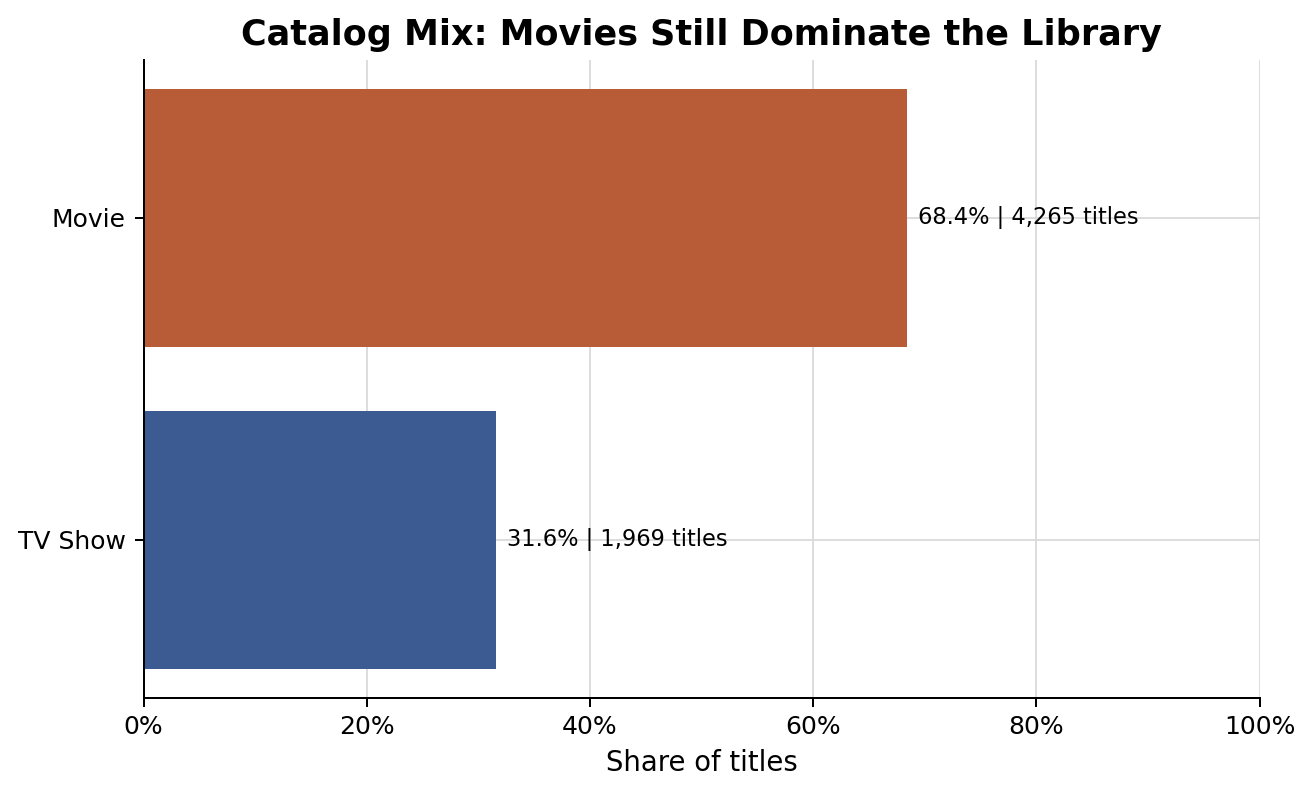

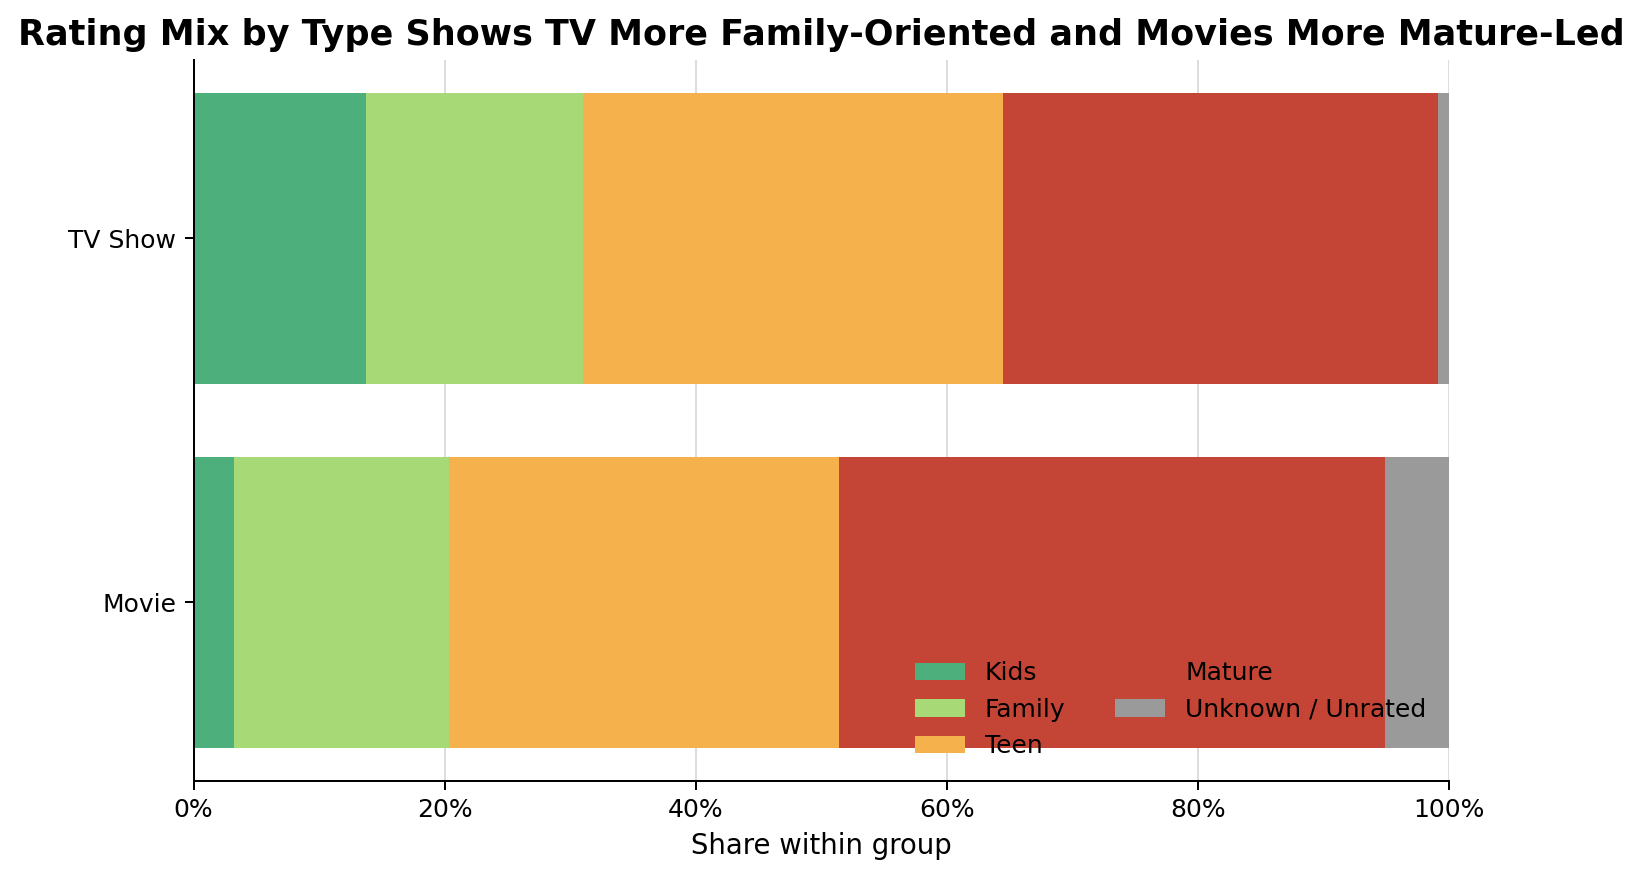

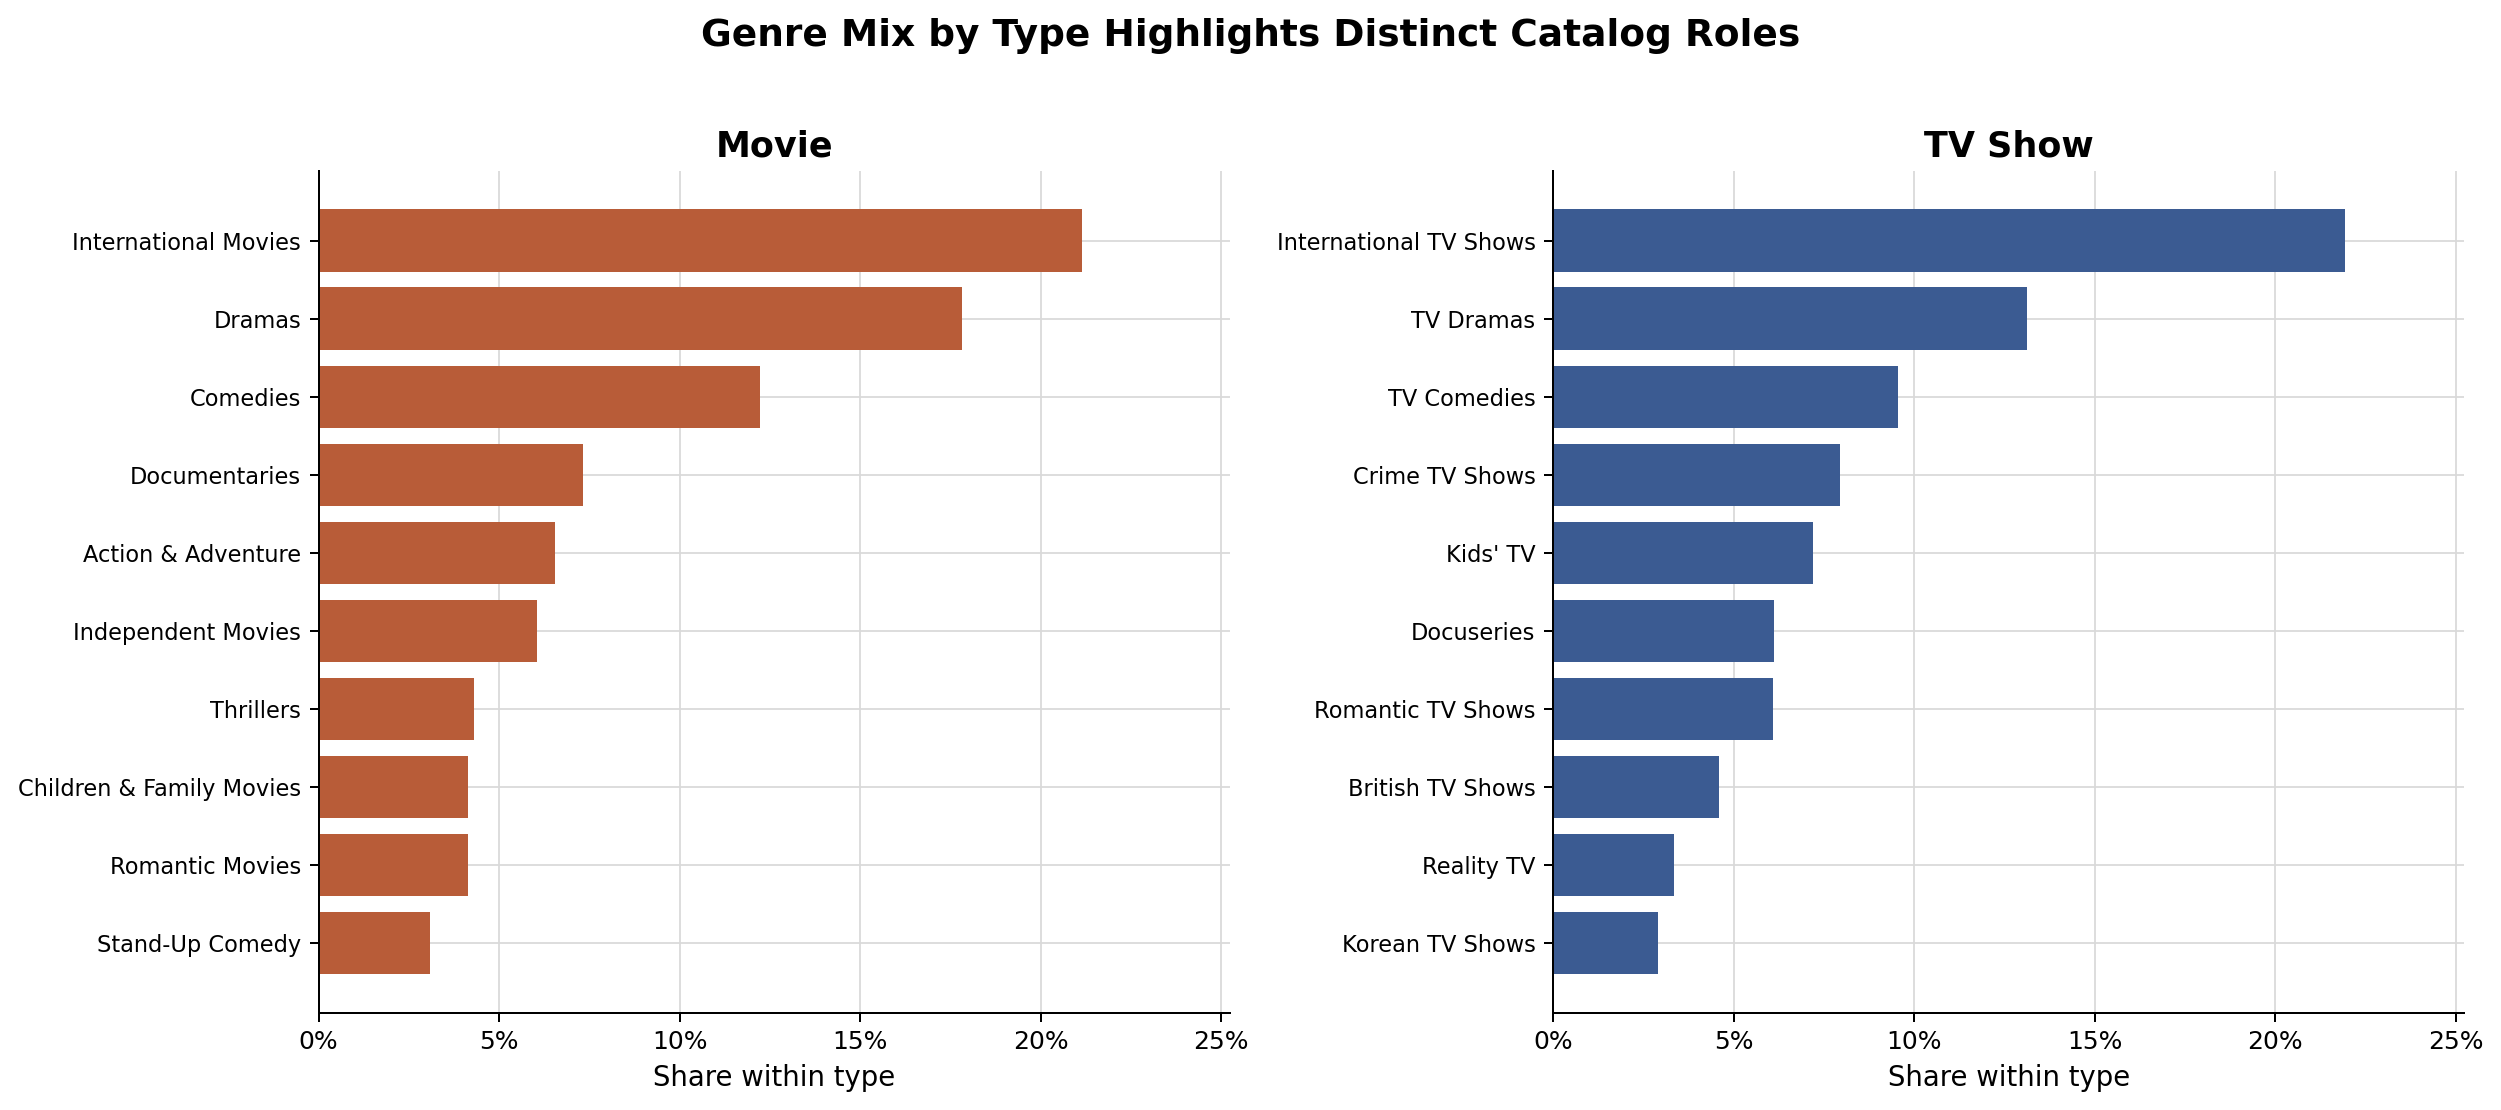

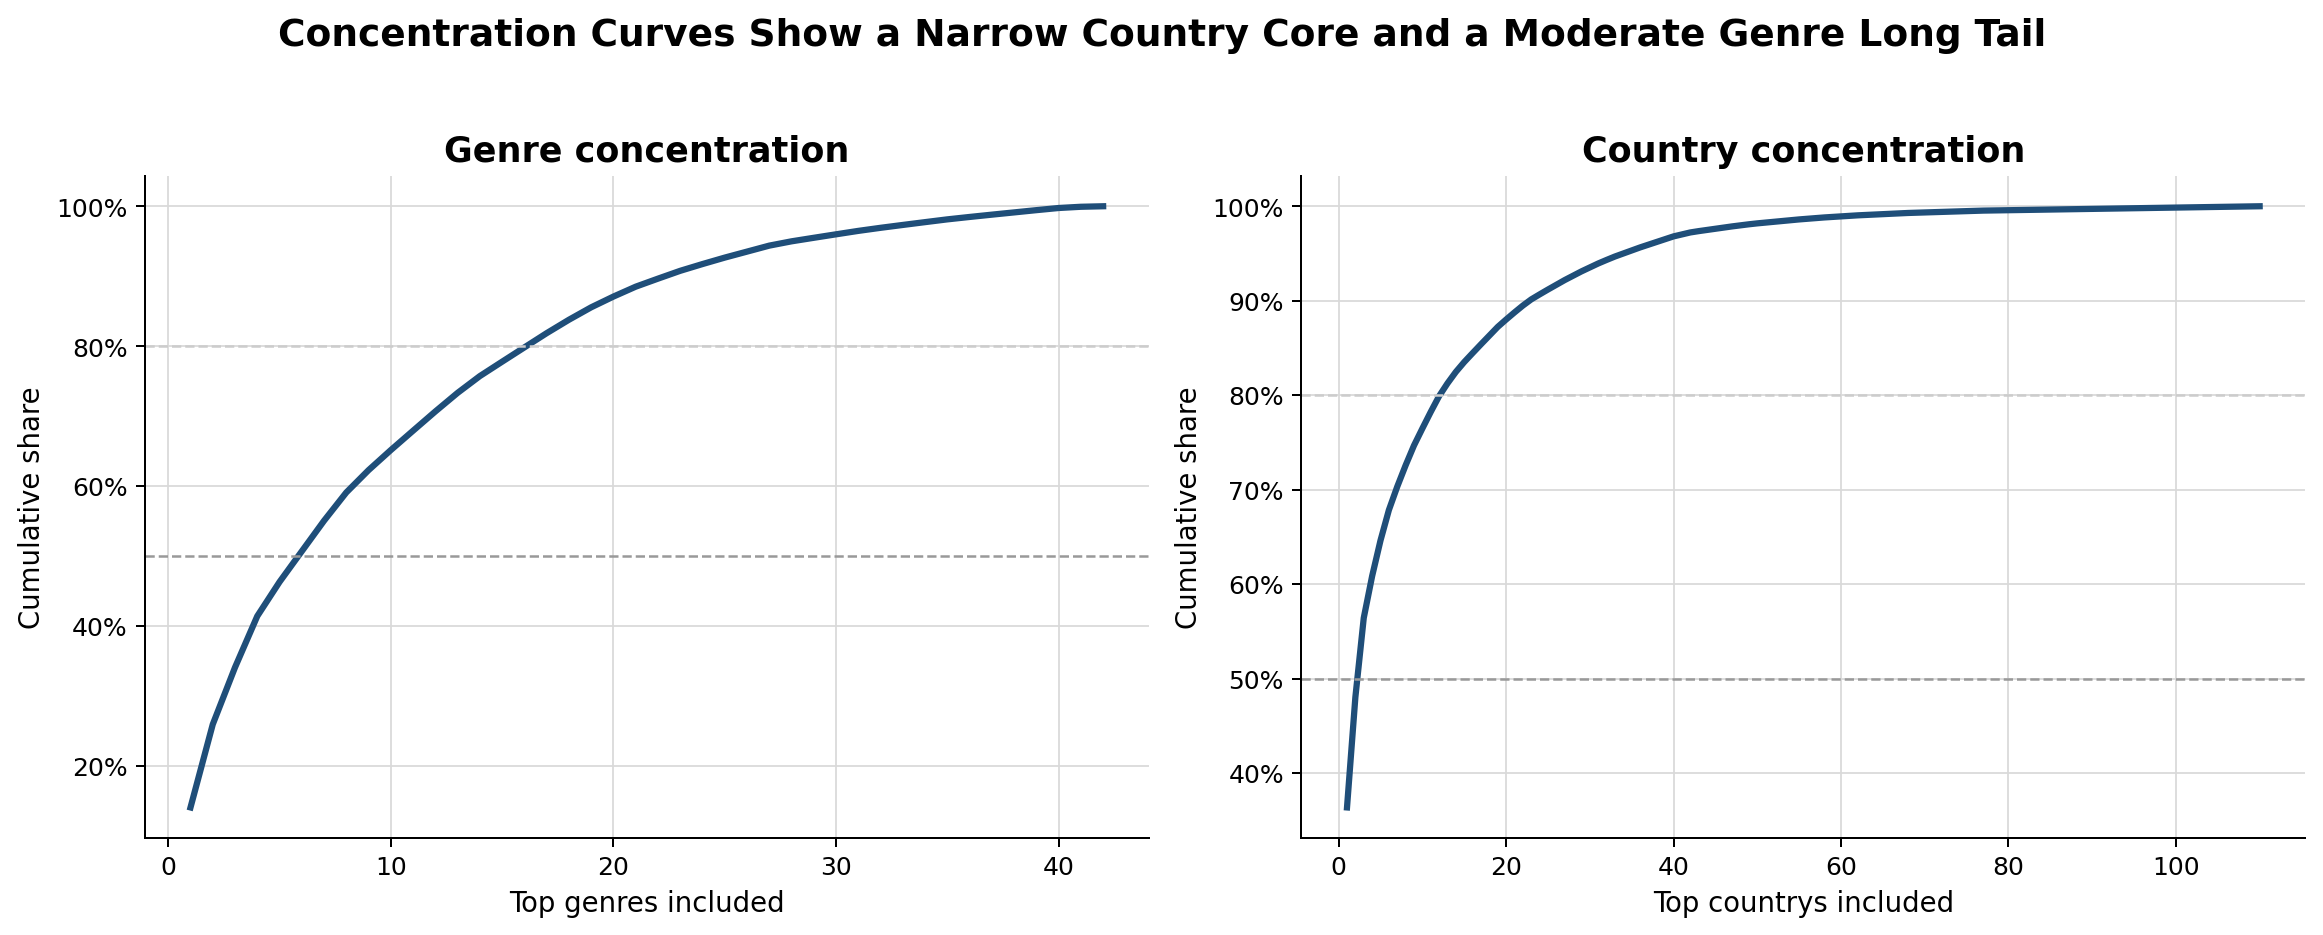

In [4]:
display(portfolio_type_mix[['type', 'title_count', 'share']])
display(concentration_summary_table[concentration_summary_table['dimension'].isin(['genre', 'country'])])
show_figure('phase2_01_catalog_type_mix.png', width=780)
show_figure('phase2_02_rating_mix_by_type.png', width=920)
show_figure('phase2_03_genre_mix_by_type.png', width=1120)
show_figure('phase2_04_concentration_curves.png', width=1120)

**Observation**

- Movies account for 68.4% of titles, so the catalog is still movie-led in volume.
- Within Movies, the largest rating bucket is `Mature` at 43.5%, while TV Shows allocate far more space to `Kids` content than Movies do.
- Genre roles are clearly differentiated: Movies lean on `International Movies`, `Dramas`, and `Comedies`, while TV Shows center on `International TV Shows`, `TV Dramas`, and `TV Comedies`.
- Concentration is meaningfully higher in country tags than in genres: 3 countries explain more than 56% of the tagged footprint, while 6 genres are needed to reach 50% of genre-tag coverage.

**Interpretation**

- Netflix appears to use Movies as the broad-volume layer of the catalog, with TV Shows playing a more curated role around distinctive audience segments.
- The genre pattern suggests a portfolio strategy built on internationally distributable drama/comedy formats rather than a highly fragmented niche catalog.
- Geographic supply is broad in absolute count, but strategically anchored to a narrow production core.

**Business relevance**

- A content strategy team would care because catalog breadth can look larger than it really is if country concentration is ignored.
- The TV-versus-Movie mix matters for acquisition planning: TV seems to carry more deliberate positioning value, while Movies provide scale.
- The concentration curves help distinguish a genuinely diversified catalog from one that is broad on the surface but operationally dependent on a small set of ecosystems.

## 2. Freshness and Release Lag

This section measures how recent the catalog looks, how quickly content tends to arrive after original release, and which dimensions look newer or older.

,type,title_count,valid_lag_title_count,median_release_year,median_lag,p75_lag,share_recent_1y,share_recent_3y,share_recent_5y
0,Movie,4265,4262,"2,016.000",1.000,6,0.503,0.646,0.721
1,TV Show,1969,1952,"2,017.000",1.000,3,0.660,0.803,0.871


,rating_group,title_count,valid_lag_title_count,median_release_year,median_lag,p75_lag,share_recent_1y,share_recent_3y,share_recent_5y
0,Mature,2537,2530,"2,017.000",1.000,3,0.645,0.770,0.830
1,Teen,1984,1978,"2,016.000",2.000,6,0.471,0.641,0.720
2,Family,1071,1069,"2,016.000",2.000,8,0.466,0.603,0.690
3,Kids,407,404,"2,017.000",1.000,3,0.639,0.780,0.859
4,Unknown / Unrated,235,233,"2,014.000",2.000,6,0.476,0.622,0.708


,genre,title_count,valid_lag_title_count,median_release_year,median_lag,p75_lag,share_recent_1y,share_recent_3y,share_recent_5y
0,International Movies,1927,1927,"2,016.000",2.000,6.000,0.460,0.639,0.735
1,Dramas,1623,1623,"2,016.000",2.000,7.000,0.444,0.617,0.701
2,Comedies,1113,1113,"2,015.000",3.000,9.000,0.416,0.553,0.629
3,International TV Shows,1001,998,"2,017.000",1.000,3.000,0.602,0.789,0.878
4,Documentaries,668,668,"2,017.000",1.000,2.000,0.695,0.856,0.909
5,TV Dramas,599,595,"2,017.000",1.000,2.000,0.713,0.844,0.908
6,Action & Adventure,597,596,"2,014.000",4.000,13.250,0.349,0.466,0.542
7,Independent Movies,552,552,"2,016.000",1.000,4.000,0.533,0.730,0.804
8,TV Comedies,436,426,"2,017.000",0.000,2.000,0.700,0.826,0.878
9,Thrillers,392,392,"2,016.000",1.000,5.000,0.531,0.686,0.773


,country,title_count,valid_lag_title_count,median_release_year,median_lag,p75_lag,share_recent_1y,share_recent_3y,share_recent_5y
0,United States,2610,2598,"2,016.000",1.000,6.000,0.577,0.680,0.736
1,India,838,838,"2,014.500",3.000,9.000,0.363,0.521,0.623
2,United Kingdom,602,601,"2,016.000",1.000,6.000,0.501,0.666,0.749
3,Canada,318,317,"2,016.000",1.000,4.000,0.546,0.713,0.785
4,France,271,271,"2,016.000",1.000,3.500,0.594,0.749,0.827
5,Japan,231,229,"2,016.000",2.000,8.000,0.463,0.559,0.642
6,Spain,178,178,"2,017.000",1.000,1.000,0.820,0.899,0.949
7,South Korea,162,162,"2,017.000",1.000,3.000,0.562,0.802,0.907
8,Germany,151,151,"2,015.000",2.000,7.500,0.450,0.616,0.709
9,Mexico,129,128,"2,017.000",0.000,2.000,0.695,0.836,0.852


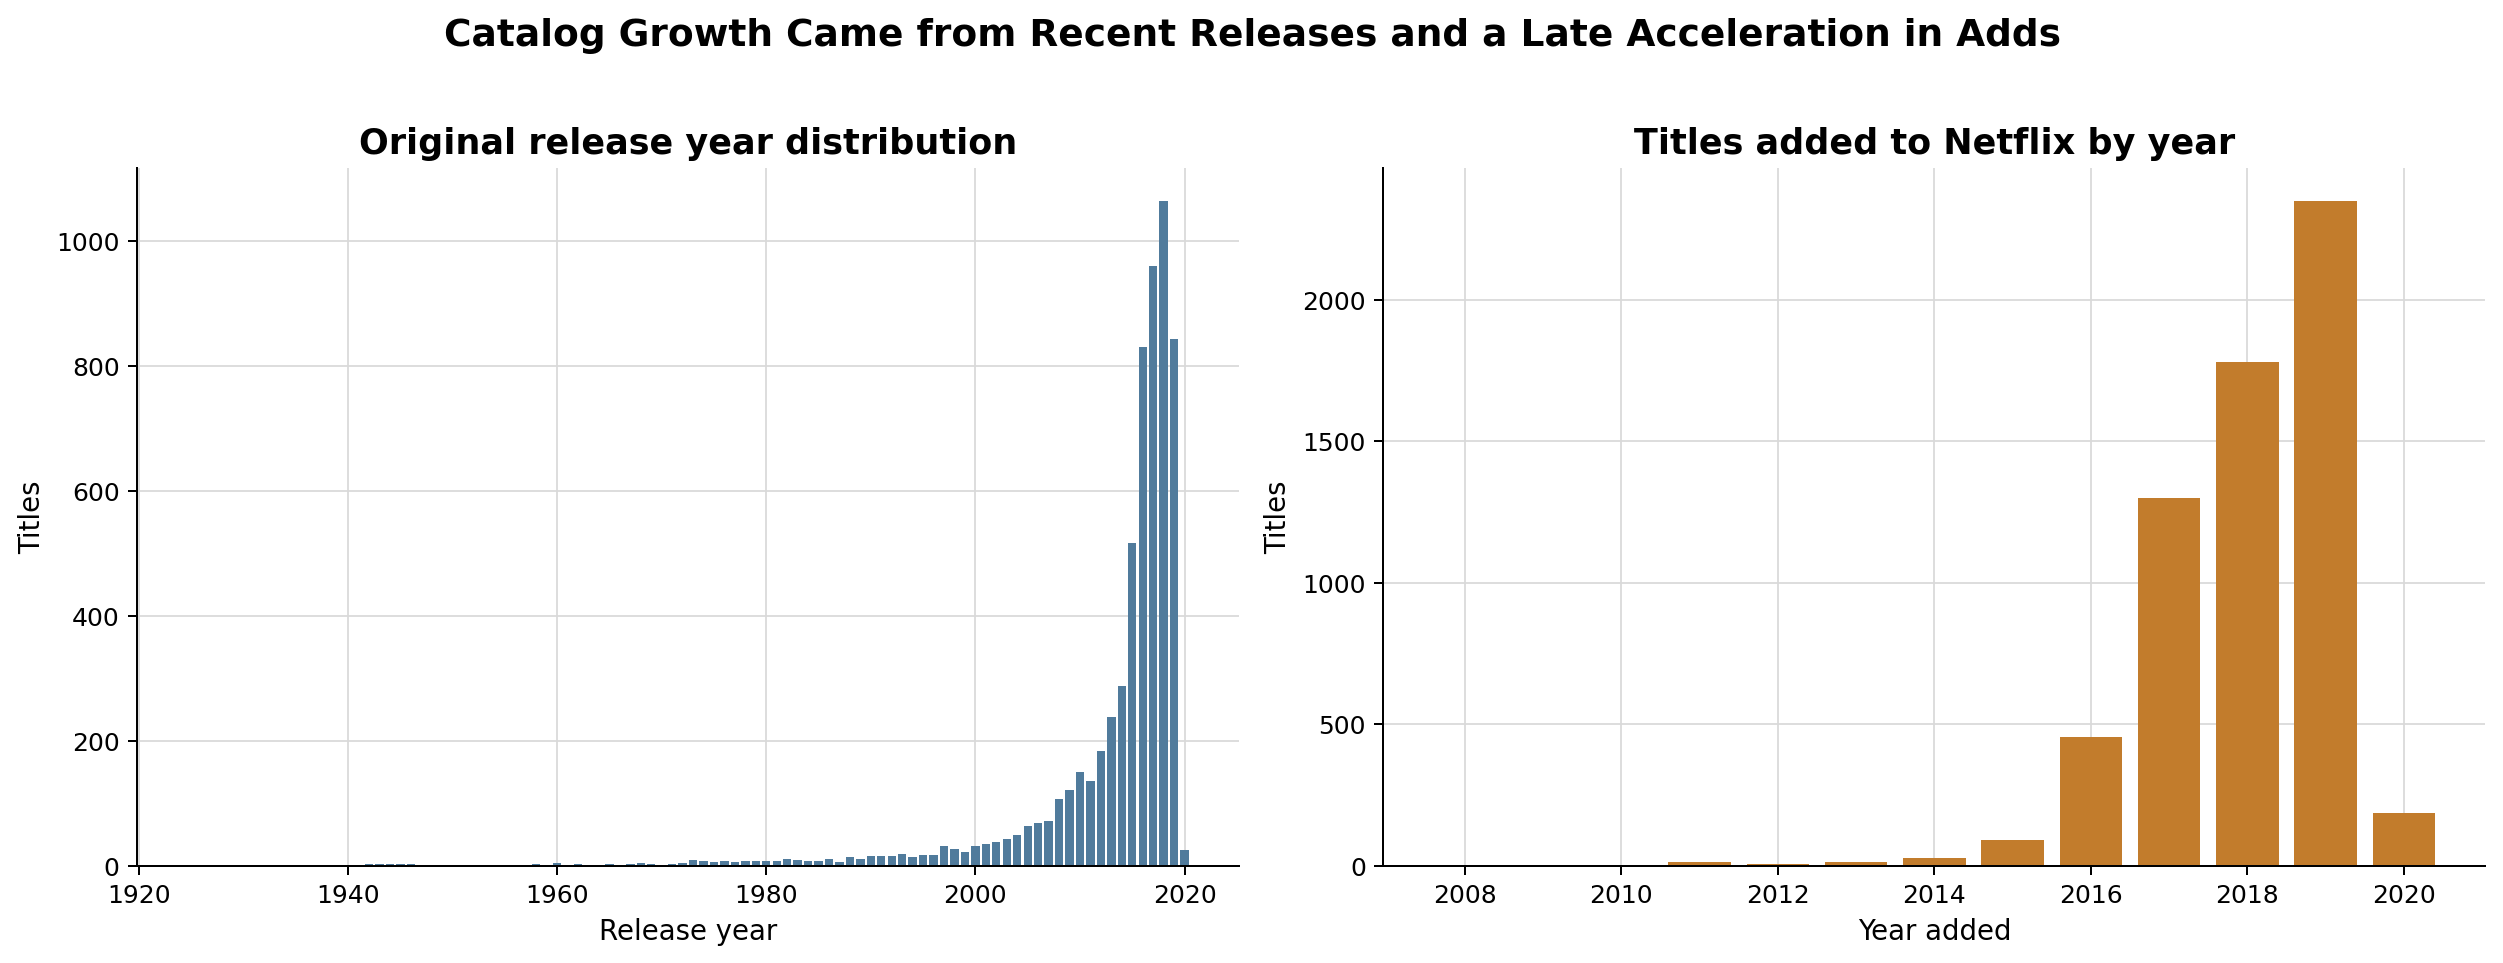

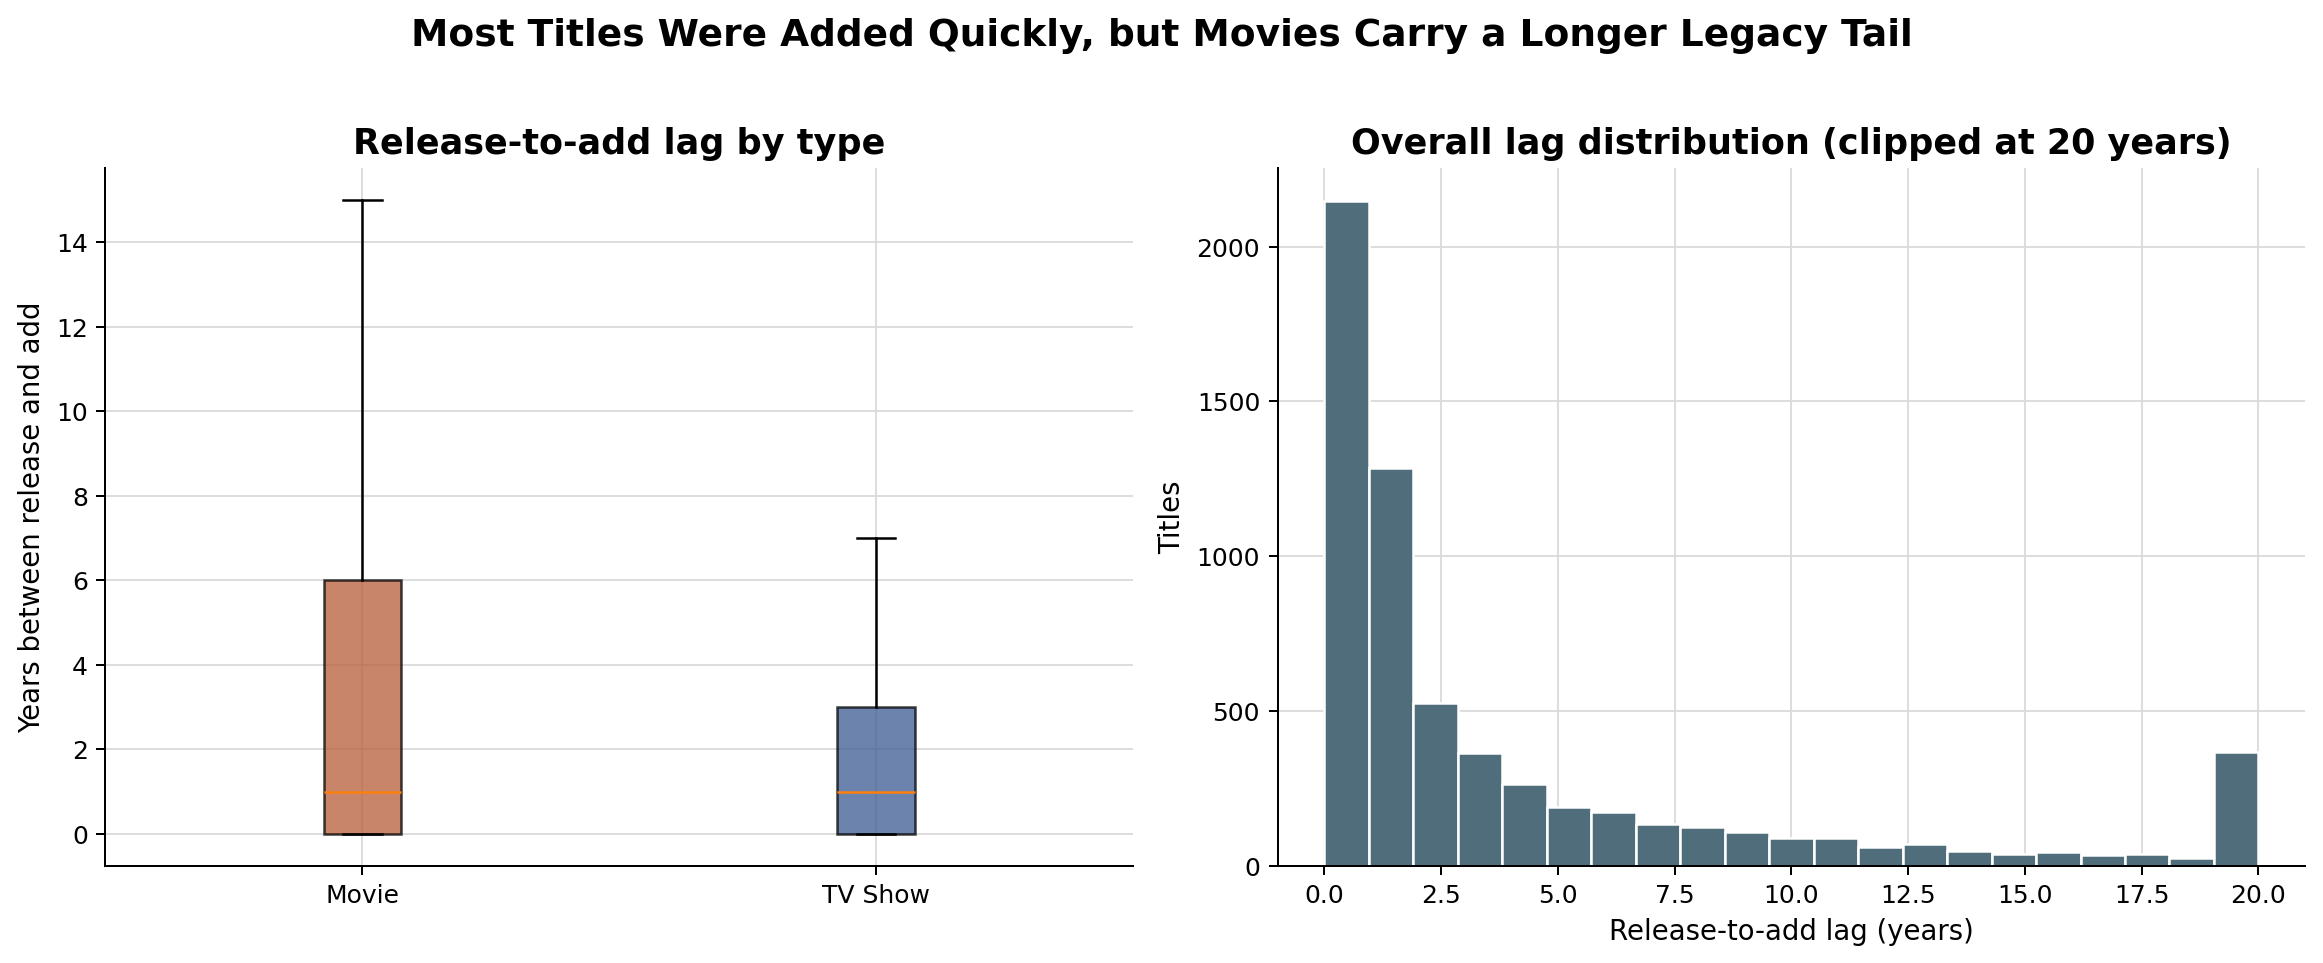

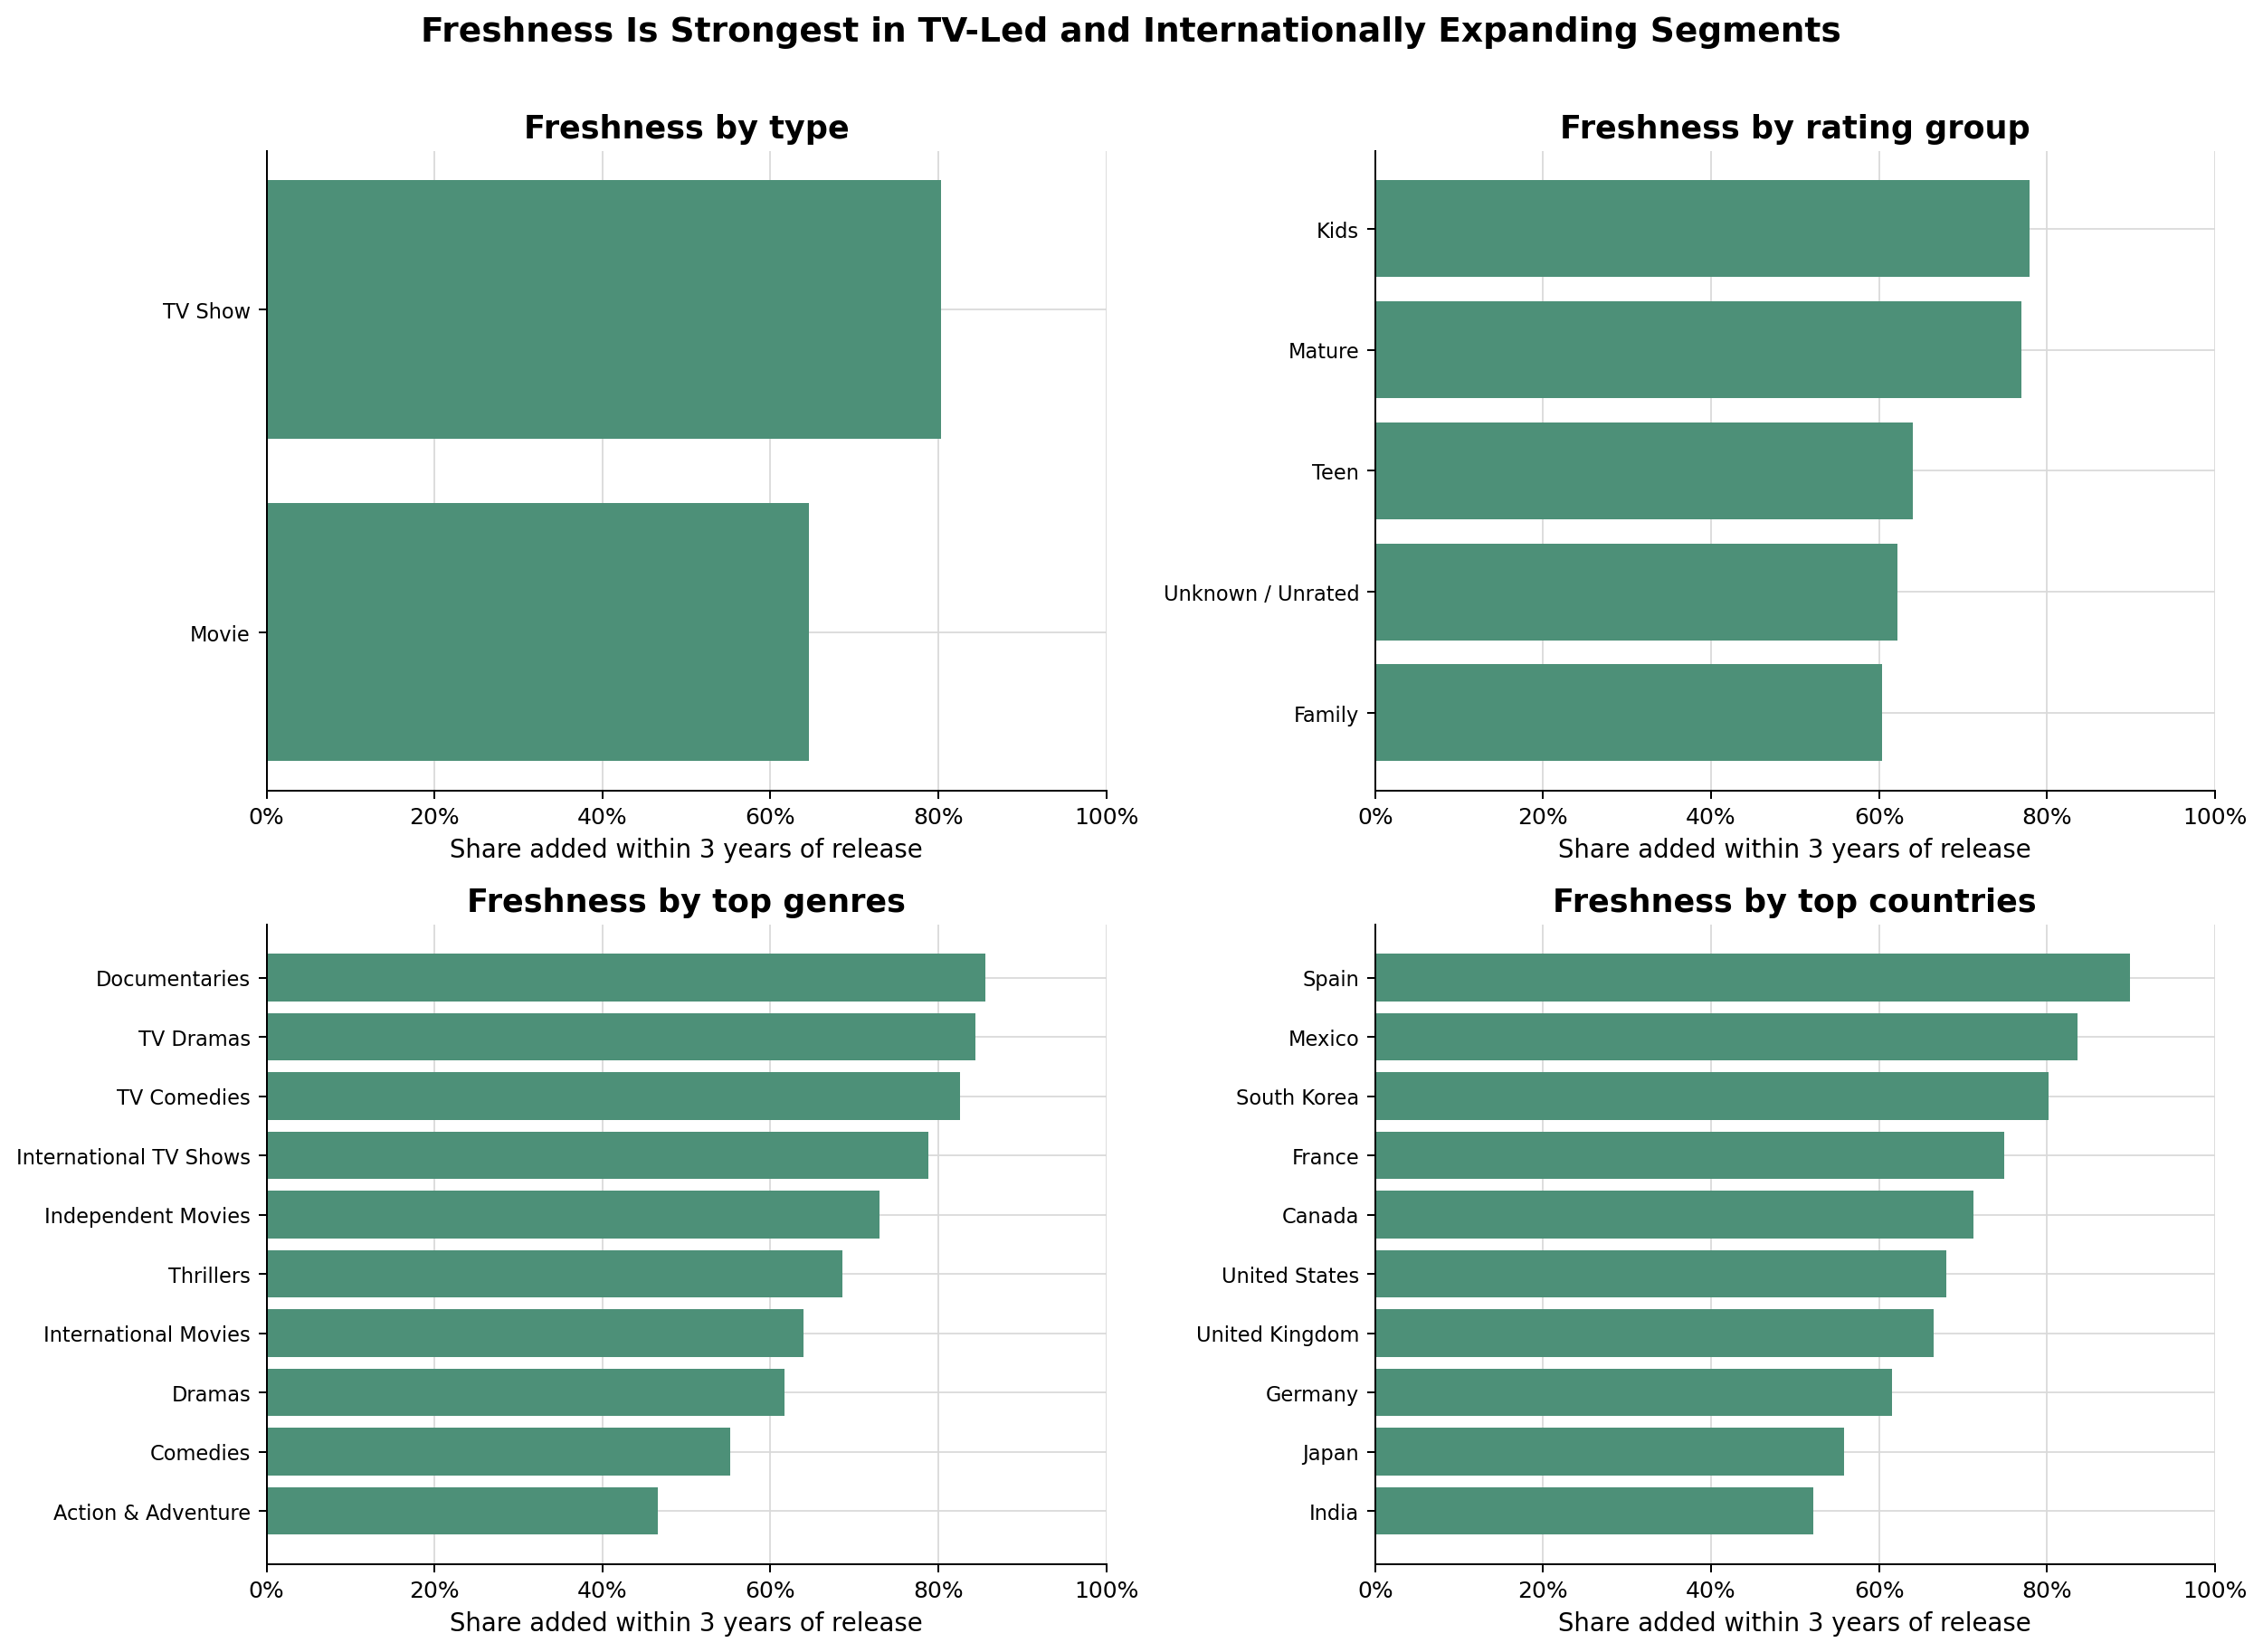

In [5]:
display(freshness_by_type)
display(freshness_by_rating)
display(freshness_by_genre.head(10))
display(freshness_by_country.head(10))
show_figure('phase2_05_release_and_add_distributions.png', width=1120)
show_figure('phase2_06_release_to_add_lag_by_type.png', width=1120)
show_figure('phase2_07_freshness_panels.png', width=1120)

**Observation**

- The catalog is visibly weighted toward recent release years, especially 2016-2019, and the number of titles added accelerated sharply in 2017-2019.
- Median release-to-add lag is only 1 year for both Movies and TV Shows, but the tails differ: TV Shows have a tighter lag profile, while Movies extend much further into legacy-library territory.
- Freshness is highest in `TV Comedies`, `Crime TV Shows`, `Documentaries`, and international TV categories.
- At the country level, Spain, Mexico, and South Korea look much fresher than older-library markets such as India or Hong Kong.

**Interpretation**

- Netflix's expansion appears to have been driven by a large intake of relatively recent titles rather than mainly by very old back-catalog acquisitions.
- TV behaves like a faster-moving strategic layer, which fits the idea that episodic content is used to keep the catalog current and differentiated.
- Freshness is not evenly distributed; it appears strongest in the segments most associated with international expansion and serialized formats.

**Business relevance**

- Catalog freshness changes how a stakeholder would think about acquisition cadence, licensing strategy, and the balance between recent titles and legacy depth.
- If a market or genre has a much older lag profile, that may imply either weaker supply access or a deliberate archival-library strategy.
- The 2020 add counts should not be overinterpreted because the dataset is a snapshot, not a full-year panel.

## 3. Geographic Footprint

The goal here is to separate true international breadth from concentration in a handful of production geographies.

,country,title_count,share,cumulative_share,entity_rank,hhi
0,United States,2610,0.364,0.364,1,0.161
1,India,838,0.117,0.480,2,0.161
2,United Kingdom,602,0.084,0.564,3,0.161
3,Canada,318,0.044,0.608,4,0.161
4,France,271,0.038,0.646,5,0.161
5,Japan,231,0.032,0.678,6,0.161
6,Spain,178,0.025,0.703,7,0.161
7,South Korea,162,0.023,0.726,8,0.161
8,Germany,151,0.021,0.747,9,0.161
9,Mexico,129,0.018,0.765,10,0.161


,type,country_scope,title_count,group_total,share_within_group
0,Movie,Missing country,195,4265,0.046
1,Movie,Single-country,3335,4265,0.782
2,Movie,Multi-country,735,4265,0.172
3,TV Show,Missing country,281,1969,0.143
4,TV Show,Single-country,1503,1969,0.763
5,TV Show,Multi-country,185,1969,0.094


,date_added_year,country,title_count,year_total,share_within_selected_entities
21,2017,United States,486,958,0.507
22,2017,India,202,958,0.211
23,2017,United Kingdom,140,958,0.146
24,2017,Canada,72,958,0.075
25,2017,France,58,958,0.061
26,2018,United States,641,1316,0.487
27,2018,India,363,1316,0.276
28,2018,United Kingdom,158,1316,0.120
29,2018,Canada,85,1316,0.065
30,2018,France,69,1316,0.052


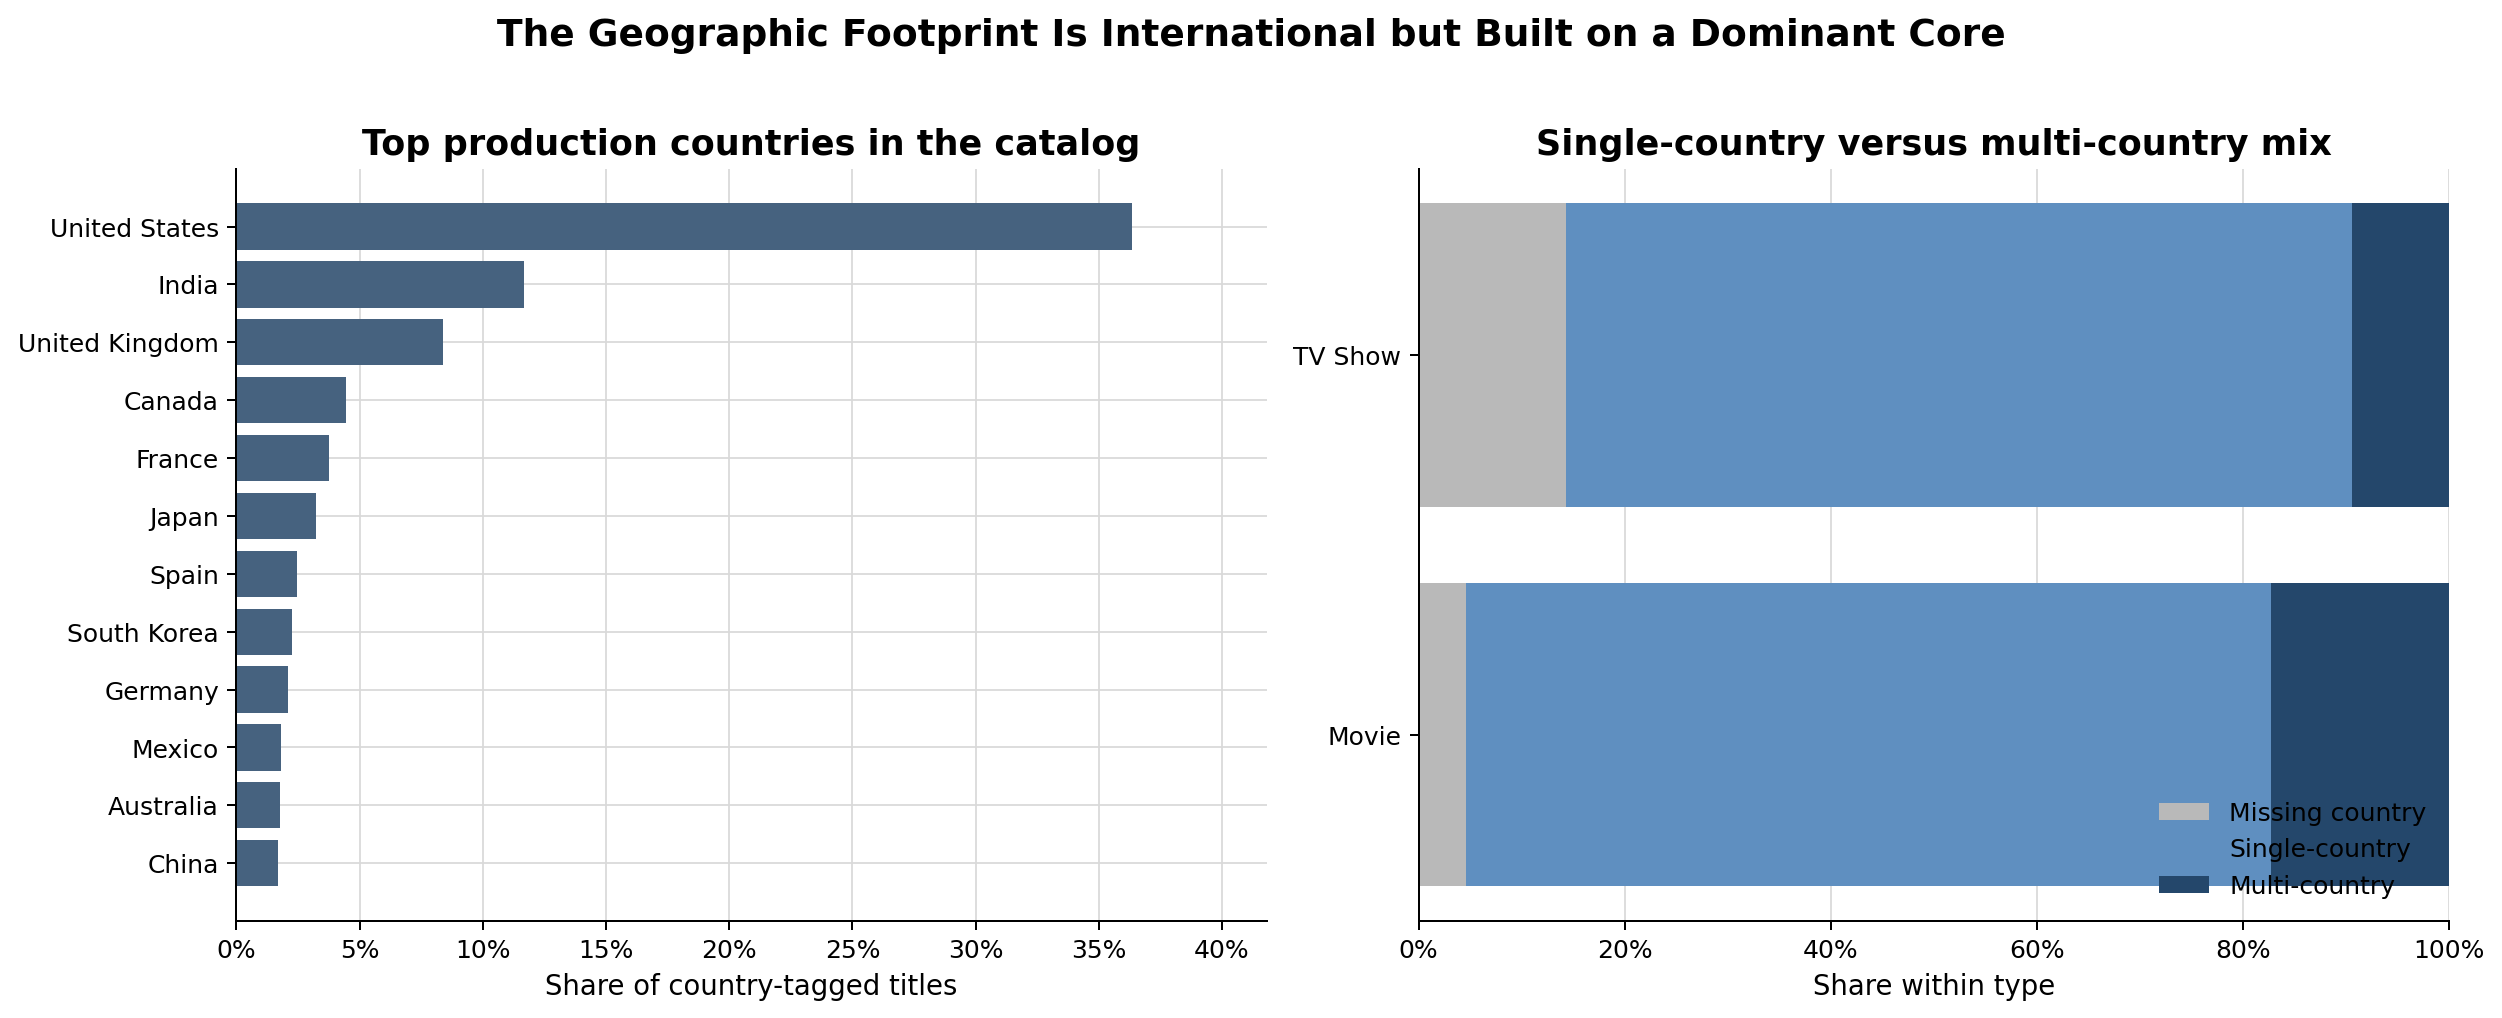

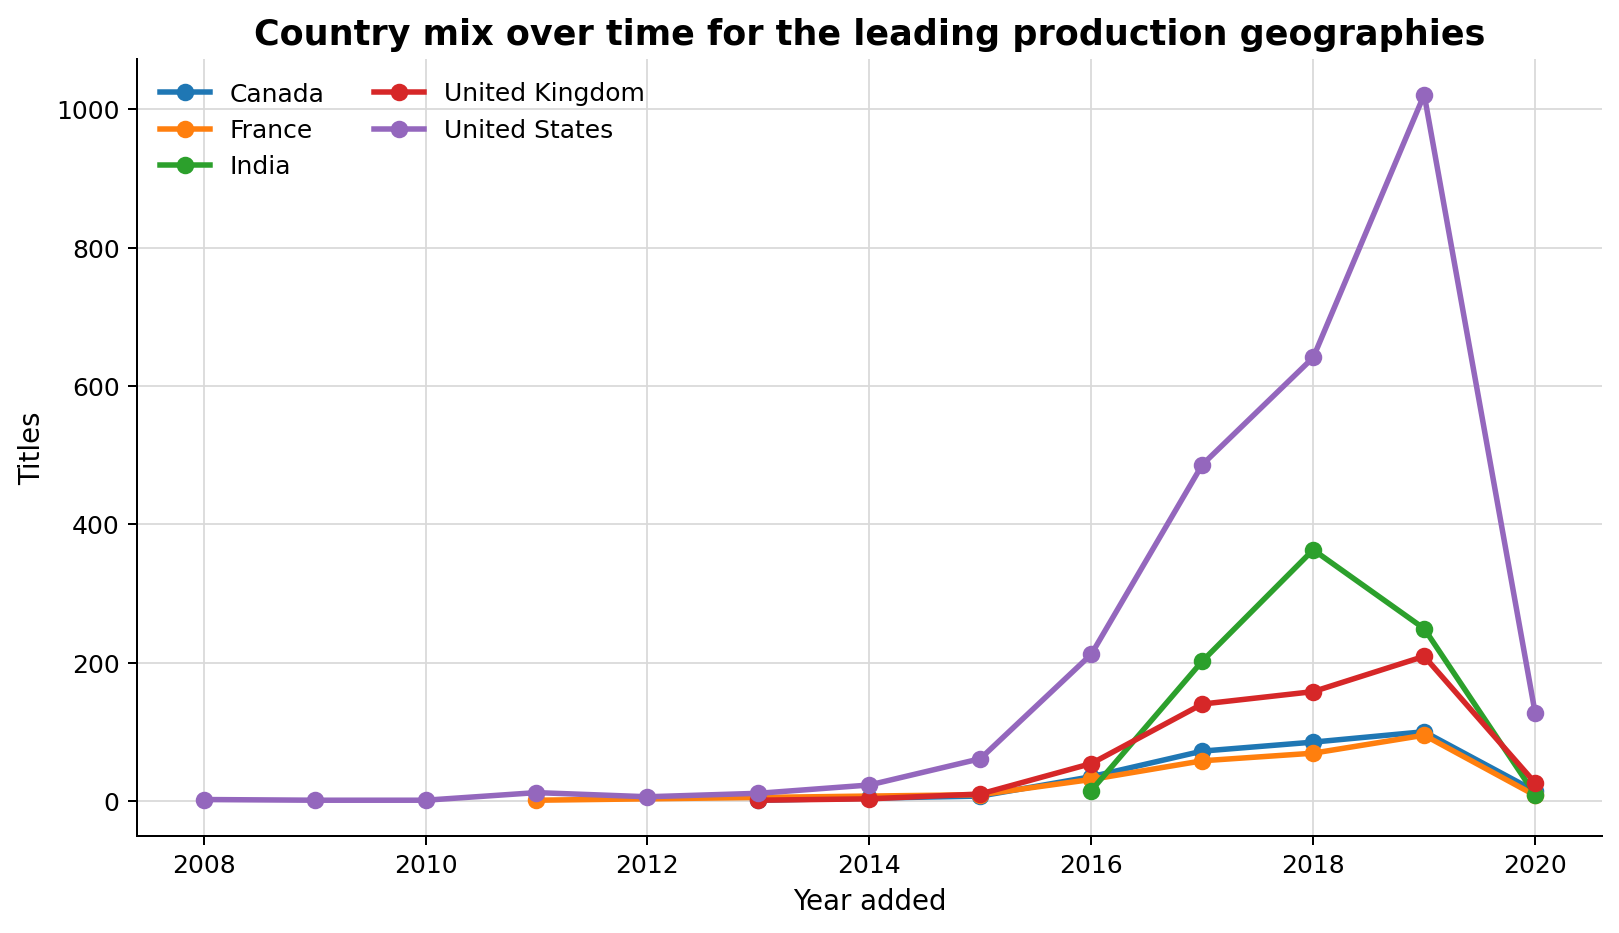

In [6]:
display(country_ranking.head(15))
display(country_scope_by_type)
display(country_mix_over_time.tail(20))
show_figure('phase2_08_country_footprint.png', width=1120)
show_figure('phase2_09_country_mix_over_time.png', width=1040)

**Observation**

- The United States alone represents 36.4% of all country-tagged titles, and the top 10 countries account for 76.5% of the footprint.
- Most titles are single-country productions, especially Movies. TV Shows are more likely than Movies to have missing country metadata, but they are less likely to be multi-country titles.
- Over time, the United States remains the dominant supply base, but India and the United Kingdom become much more visible in the 2017-2019 expansion wave.

**Interpretation**

- The catalog is international, but not evenly global. It is better described as a concentrated global portfolio built on a small production core.
- The rise of India in the later add years suggests that international scale was not just about adding more countries, but about deepening a few strategically important ones.
- Single-country dominance also implies that the country footprint reflects discrete production ecosystems more than heavily co-produced catalog design.

**Business relevance**

- This matters for localization and acquisition strategy because growth can come either from broadening the long tail or deepening the strongest non-U.S. production hubs.
- A stakeholder looking at market coverage would want to know whether geographic diversification is real or whether the catalog is still operationally concentrated.
- Country-tag analysis is a structural catalog lens, not a market-demand lens; it says where supply comes from, not how well it performs.

## 4. Audience Positioning

This section uses the harmonized rating groups to infer which audience segments the catalog appears to target overall and within major genres and countries.

,rating_group,title_count,share
0,Mature,2537,0.407
1,Teen,1984,0.318
2,Family,1071,0.172
3,Kids,407,0.065
4,Unknown / Unrated,235,0.038


,genre,rating_group,title_count,group_total,share_within_group,rank_within_group
0,Action & Adventure,Mature,295,597,0.494,1
1,Action & Adventure,Teen,241,597,0.404,2
2,Action & Adventure,Family,33,597,0.055,3
3,Action & Adventure,Unknown / Unrated,27,597,0.045,4
4,Action & Adventure,Kids,1,597,0.002,5
5,Comedies,Teen,430,1113,0.386,1
6,Comedies,Mature,367,1113,0.330,2
7,Comedies,Family,251,1113,0.226,3
8,Comedies,Unknown / Unrated,34,1113,0.031,4
9,Comedies,Kids,31,1113,0.028,5


,country,rating_group,title_count,group_total,share_within_group,rank_within_group
0,Canada,Mature,124,318,0.390,1
1,Canada,Family,66,318,0.208,2
2,Canada,Teen,62,318,0.195,3
3,Canada,Kids,55,318,0.173,4
4,Canada,Unknown / Unrated,11,318,0.035,5
5,France,Mature,142,271,0.524,1
6,France,Teen,52,271,0.192,2
7,France,Family,34,271,0.125,3
8,France,Kids,29,271,0.107,4
9,France,Unknown / Unrated,14,271,0.052,5


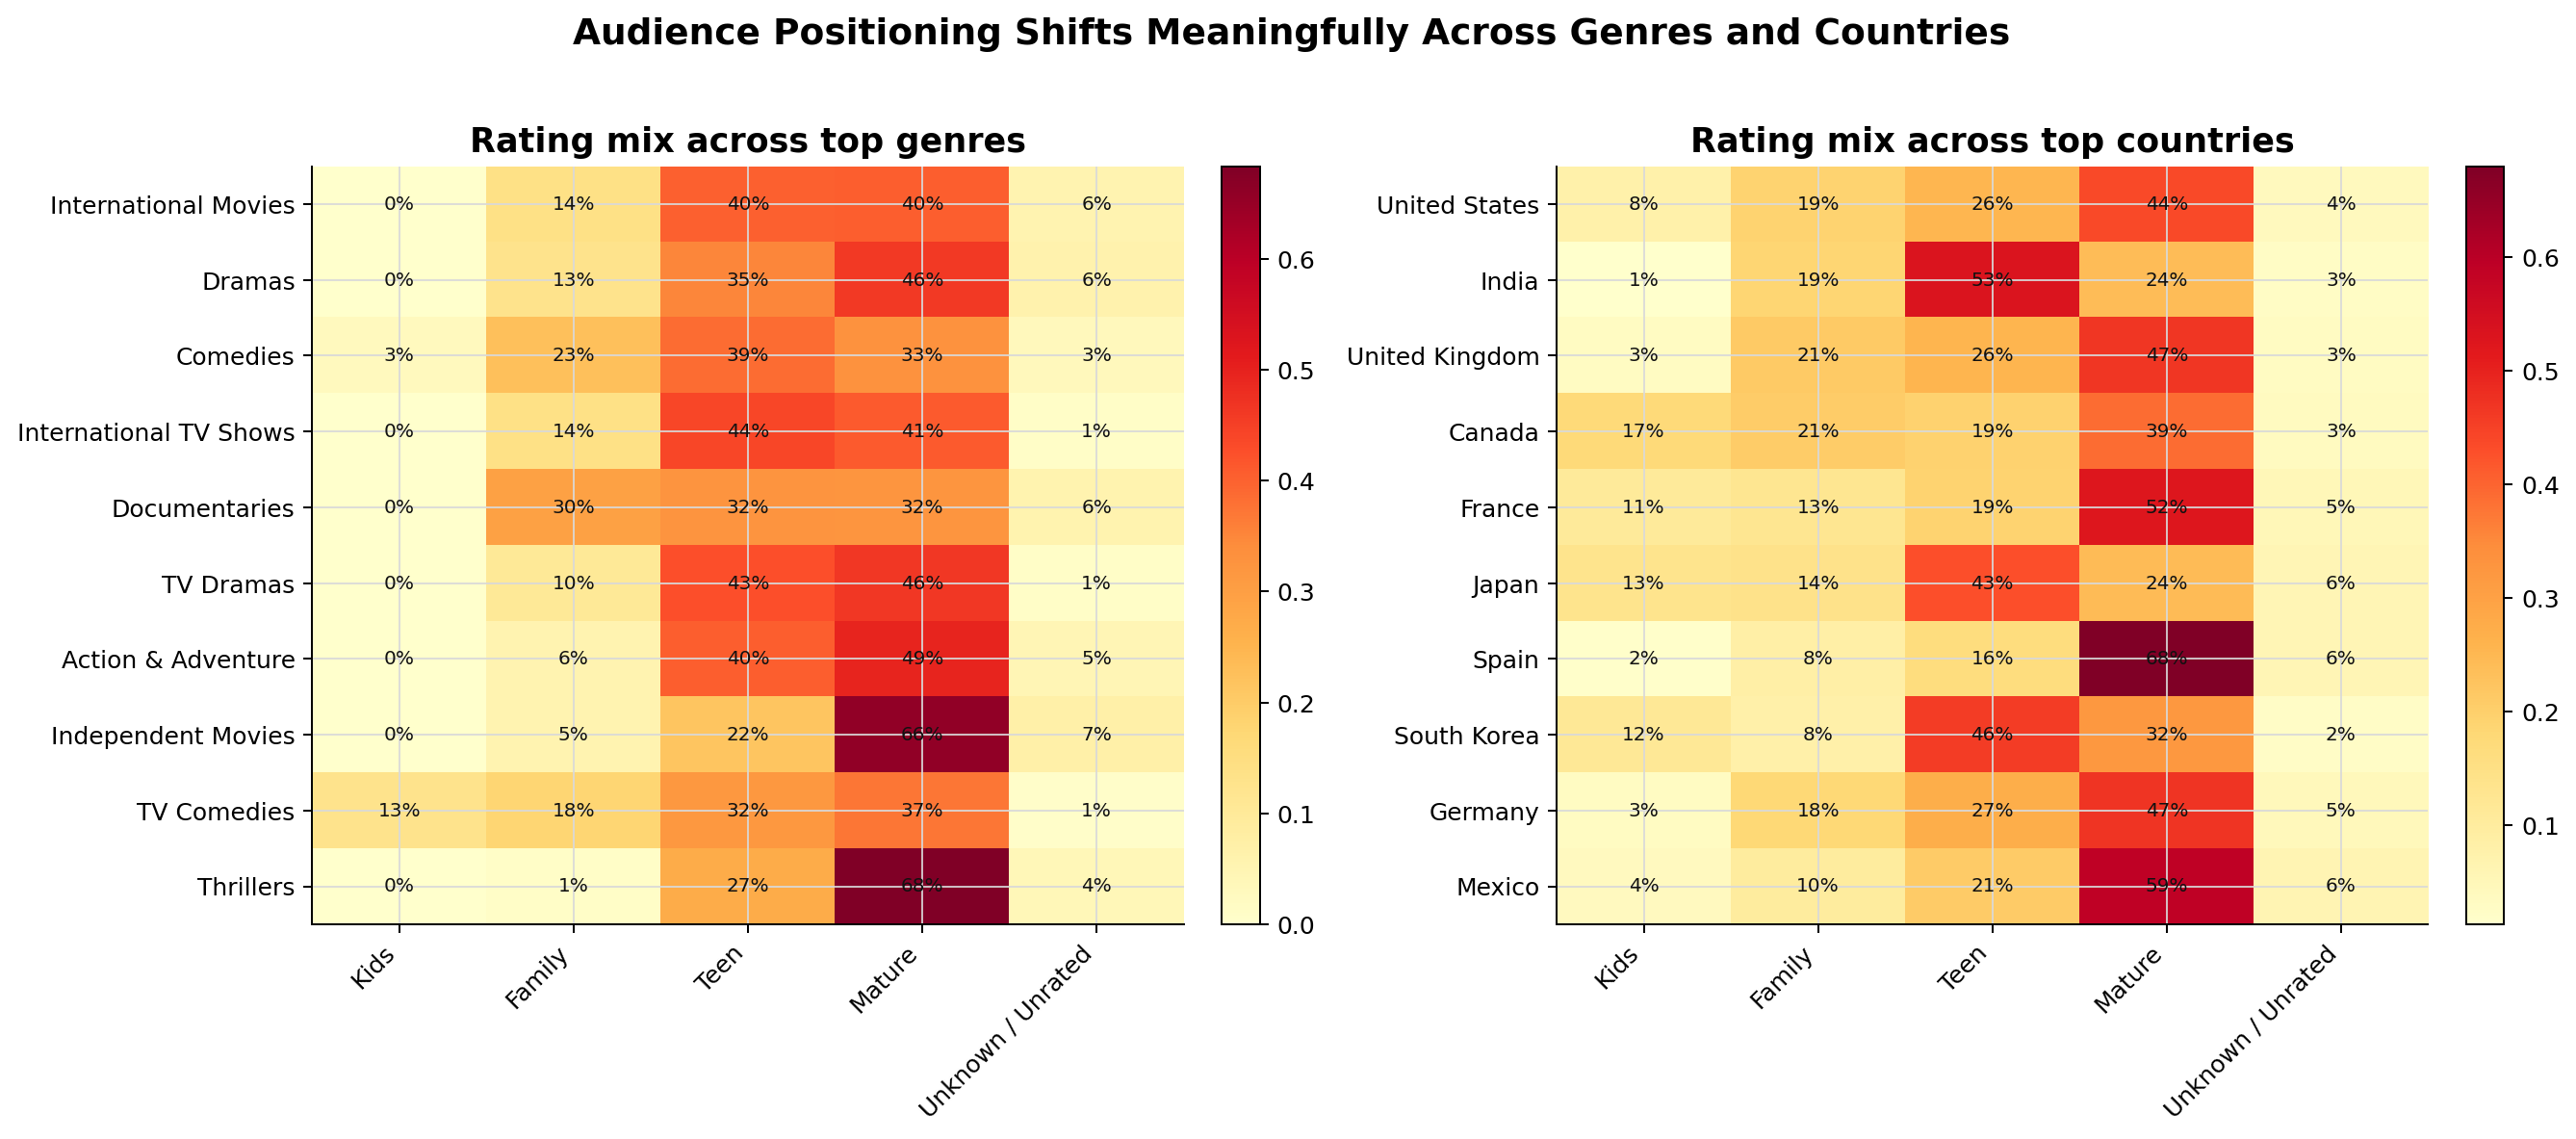

In [7]:
display(rating_distribution_overall[['rating_group', 'title_count', 'share']])
display(rating_by_genre.head(20))
display(rating_by_country.head(20))
show_figure('phase2_10_rating_positioning_heatmaps.png', width=1200)

**Observation**

- Overall positioning skews mature: `Mature` and `Teen` together account for almost 72.5% of titles.
- Some high-volume genres are especially mature-skewed, including `Thrillers`, `Independent Movies`, `Crime TV Shows`, and `Stand-Up Comedy`.
- Country-level positioning varies substantially: Spain, Mexico, France, and Hong Kong are much more mature-skewed than India, Japan, or Taiwan.
- TV Shows are not less mature overall, but they do allocate meaningfully more inventory to Kids content than Movies do.

**Interpretation**

- Netflix's catalog looks adult-led by default, with family and kids content present but not dominant.
- Audience targeting is not uniform across the footprint; some country ecosystems appear to supply more mature or more family-oriented catalogs.
- The genre-country heatmaps suggest that rating mix is part of catalog positioning, not just a compliance artifact.

**Business relevance**

- This helps frame content strategy around audience balance: whether the catalog is over-indexing on mature inventory, where family-safe supply is concentrated, and which genre-country combinations support different audience needs.
- It is especially useful for portfolio communication, because it translates messy ratings into interpretable positioning buckets without making unsupported claims about what performs better.

## 5. Genre Concentration and Co-Occurrence

The final module looks at how genres combine, where the catalog has clear strategic bundles, and where pairings are structurally weak or absent.

,entity_a,entity_b,pair_count,lift
0,International TV Shows,TV Dramas,398,4.138
1,Dramas,Independent Movies,413,2.874
2,Comedies,Romantic Movies,168,2.503
3,Children & Family Movies,Comedies,168,2.489
4,International TV Shows,TV Comedies,170,2.428
5,International Movies,Romantic Movies,236,2.031
6,Dramas,International Movies,1017,2.027
7,TV Comedies,TV Dramas,80,1.910
8,Dramas,Romantic Movies,177,1.808
9,Dramas,Thrillers,174,1.705


,entity_a,entity_b,pair_count,expected_count,lift
34,Action & Adventure,International TV Shows,0,95.861,0.000
35,Action & Adventure,TV Comedies,0,41.754,0.000
36,Action & Adventure,TV Dramas,0,57.363,0.000
37,Children & Family Movies,International TV Shows,0,60.696,0.000
39,Children & Family Movies,TV Dramas,0,36.321,0.000
41,Comedies,International TV Shows,0,178.716,0.000
42,Comedies,TV Comedies,0,77.842,0.000
43,Comedies,TV Dramas,0,106.944,0.000
44,Documentaries,Independent Movies,0,59.149,0.000
45,Documentaries,International TV Shows,0,107.261,0.000


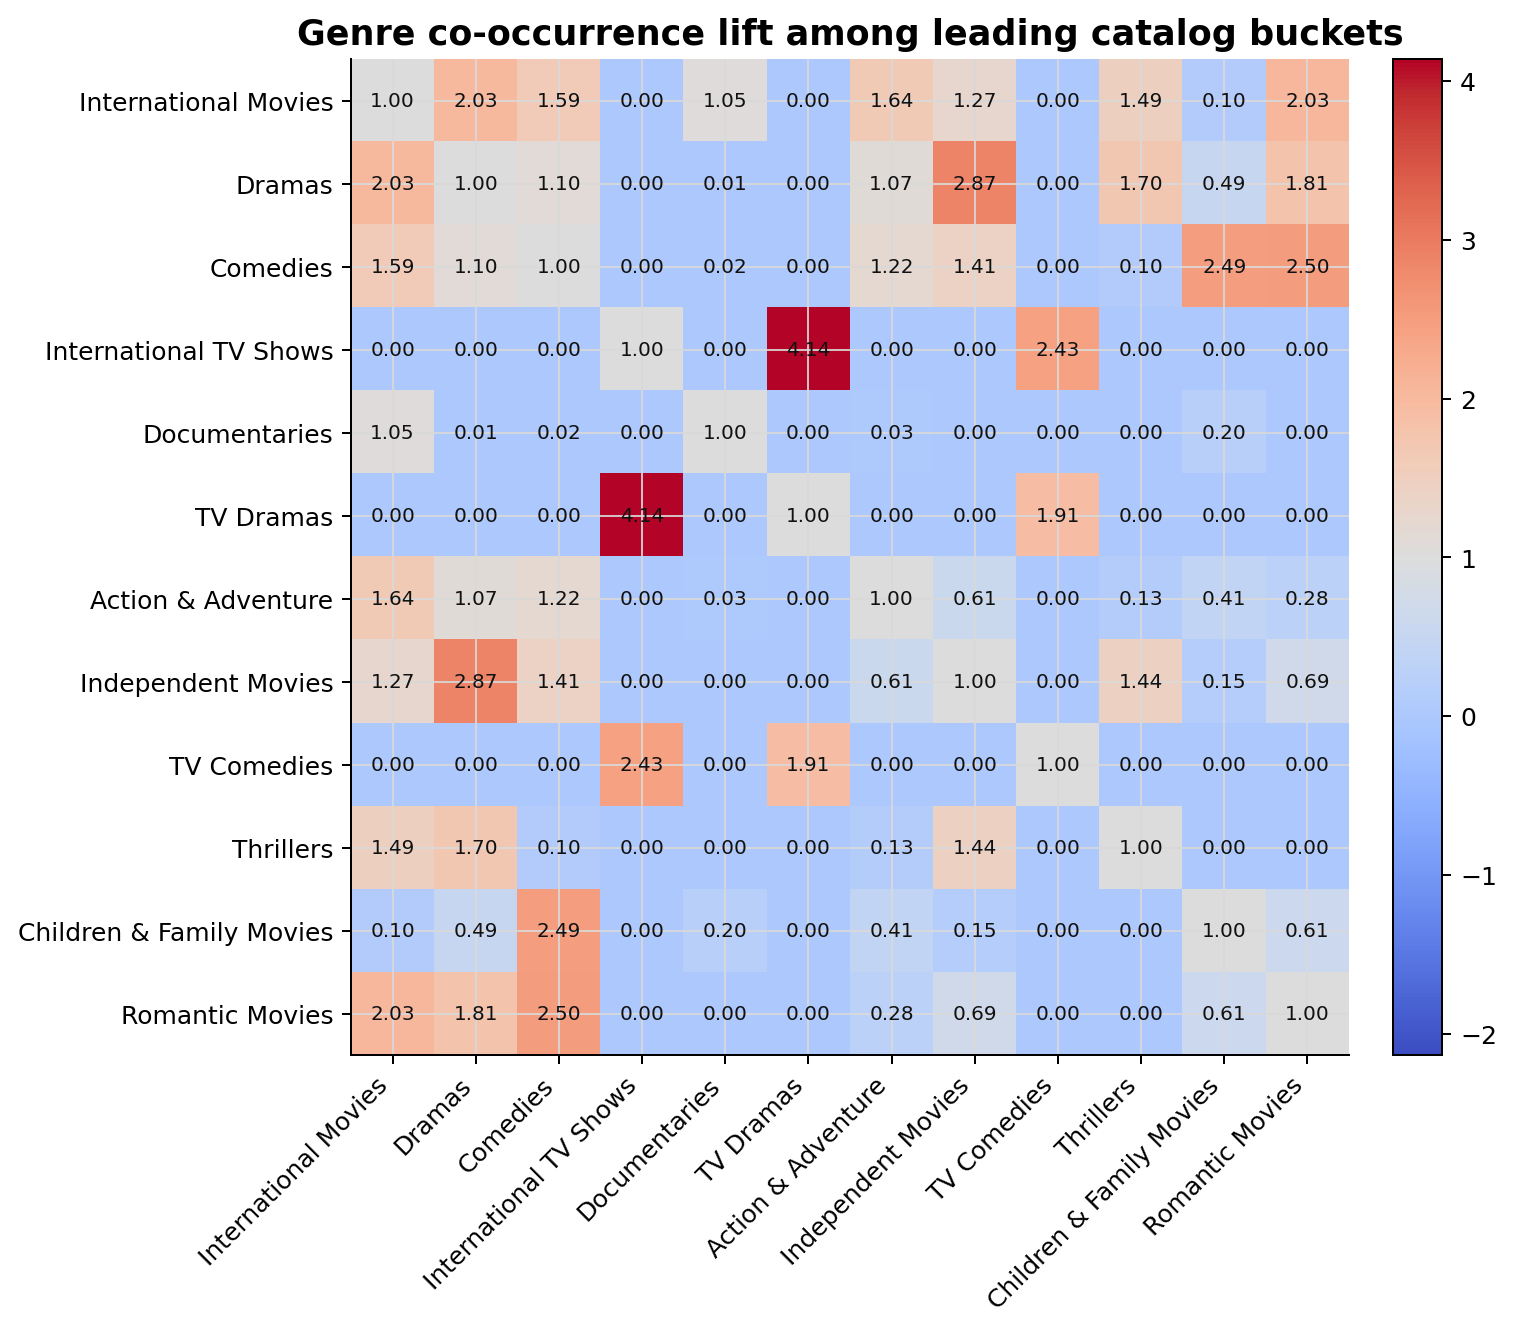

In [8]:
display(genre_pair_lift_high[['entity_a', 'entity_b', 'pair_count', 'lift']])
display(genre_pair_lift_low[['entity_a', 'entity_b', 'pair_count', 'expected_count', 'lift']])
show_figure('phase2_11_genre_pair_lift_heatmap.png', width=940)

**Observation**

- The strongest positive pairings include `International TV Shows` with `TV Dramas`, `Dramas` with `Independent Movies`, and `Comedies` with `Romantic Movies`.
- The co-occurrence heatmap also shows large blocks of zero or near-zero overlap between movie-specific and TV-specific genre systems.
- `Dramas` and `International Movies` are not just large individually; they also co-occur at roughly double the volume expected under independence.

**Interpretation**

- The catalog is segmented into interpretable bundles rather than random genre combinations. That is exactly what a strategy analyst would want to see when looking for coherent portfolio structures.
- Some low-overlap combinations are not weaknesses; they reflect structurally separate content systems for Movies and TV Shows.
- The strongest positive pairings reveal reusable catalog recipes, especially around international drama and romance-heavy bundles.

**Business relevance**

- Co-occurrence patterns can inform how the catalog is merchandised, how content families are framed, and how acquisition teams think about complementary supply.
- They also set up Phase 3 naturally: the pair-lift structure is a strong foundation for segmentation and clustering rather than jumping directly to black-box methods.

## Phase 2 Takeaways

### Major findings

- The catalog is movie-led in volume, but TV behaves like a more focused strategic layer.
- The maturity mix is adult-skewed overall, with clear genre- and country-level differences in audience positioning.
- Netflix's footprint is international but structurally concentrated in a small set of production countries.
- Freshness is strongest in TV-led and international-expansion segments, while older-library behavior is more visible in some movie and country pockets.
- Genre co-occurrence reveals coherent content bundles rather than a flat taxonomy.

### Strongest charts

- `phase2_02_rating_mix_by_type.png`
- `phase2_03_genre_mix_by_type.png`
- `phase2_04_concentration_curves.png`
- `phase2_06_release_to_add_lag_by_type.png`
- `phase2_07_freshness_panels.png`
- `phase2_08_country_footprint.png`
- `phase2_10_rating_positioning_heatmaps.png`
- `phase2_11_genre_pair_lift_heatmap.png`

### Data limitations relevant to the findings

- Country totals reflect multi-tagged production geography, not mutually exclusive title shares.
- Rating groups are harmonized analytical buckets, not strict regulatory equivalences.
- The 2020 add year is snapshot-limited and should not be treated as a full year trend.
- Missing country metadata is materially higher for TV Shows than Movies.
- The dataset supports catalog structure, not content performance.

### Recommendation for Phase 3

Use the pair-lift structure, title-level features, and normalized people tables to build interpretable title segments and creator/cast networks. The strongest next step is not more descriptive charting; it is a segmentation layer that labels recurring catalog strategies such as internationally distributed drama clusters, kids/family TV bundles, and mature long-tail movie niches.